The **Air Quality Index (AQI)** is a tool used by government agencies to simplify complex air quality data into a single number, a simple description, and a color code. Its primary purpose is to communicate the daily air quality status and associated health risks to the public.

Categories: The index is grouped into color-coded categories, such as:





Good (0-50)


Satisfactory (51-100)

Moderately Polluted (101-200)

Poor (201-300)

Very Poor (301-400)

Severe (401-500)

### Air Quality Index (AQI) Calculation

The AQI is calculated based on the concentrations of individual pollutants. For each pollutant, a sub-index is calculated using specific breakpoints and formulas. The overall AQI for a location is the maximum of the sub-indices of the individual pollutants.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
aqi = pd.read_excel('AQI_data.xlsx')

In [ ]:
aqi.isnull().sum()

,0
State / Union Territory,0
City/town,0
SO2,14
NO2,9
PM_10,7
PM_2.5,99


In [ ]:
aqi.shape

(850, 6)

In [ ]:
aqi.sample(20)

,State / Union Territory,City/town,SO2,NO2,PM_10,PM_2.5
424,Mizoram,Lunglei,2,5,12,NaN
222,Jharkhand,Dhanbad,26,65,156,73
439,Nagaland,Kohima,3,8,73,36
138,Gujarat,Vapi,27,27,116,62
3,Andhra Pradesh,Chittoor,5,11,57,33
87,Bihar,Munger,23,31,193,76
395,Maharashtra,Pimpri Chinchwad,12,50,100,53
263,Karnataka,Hassan,18,15,70,29
524,Punjab,Barnala,7,17,98,NaN
177,Haryana,Kurukshetra,12,24,117,66


In [ ]:
columns_to_process = ['SO2', 'NO2', 'PM_10', 'PM_2.5']

# Replace 'NM' and string 'NaN' with actual np.nan in the specified columns
for col in columns_to_process:
    aqi[col] = aqi[col].replace({'NM': np.nan, 'NaN': np.nan})

# Convert columns to numeric, coercing any remaining non-numeric to NaN
aqi[columns_to_process] = aqi[columns_to_process].apply(pd.to_numeric, errors='coerce')

# Drop rows where any of these specific columns have NaN
aqi.dropna(subset=columns_to_process, inplace=True)

/tmp/ipython-input-1335641812.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  aqi[col] = aqi[col].replace({'NM': np.nan, 'NaN': np.nan})


AQI Calculations:-->

In [ ]:
def calculate_sub_index(concentration, bp_low, bp_high, ip_low, ip_high):
    """Calculates the sub-index for a given pollutant concentration."""
    # Handle cases where concentration is outside the defined breakpoints
    if concentration <= bp_low:
        return ip_low
    if concentration >= bp_high:
        return ip_high

    # Linear interpolation formula
    sub_index = ((ip_high - ip_low) / (bp_high - bp_low)) * (concentration - bp_low) + ip_low
    return round(sub_index)

def get_aqi_so2(so2_concentration):
    """Calculates the AQI sub-index for SO2 concentration."""
    if pd.isna(so2_concentration): return np.nan
    if 0 <= so2_concentration <= 40: return calculate_sub_index(so2_concentration, 0, 40, 0, 50)
    elif 41 <= so2_concentration <= 80: return calculate_sub_index(so2_concentration, 41, 80, 51, 100)
    elif 81 <= so2_concentration <= 380: return calculate_sub_index(so2_concentration, 81, 380, 101, 200)
    elif 381 <= so2_concentration <= 800: return calculate_sub_index(so2_concentration, 381, 800, 201, 300)
    elif 801 <= so2_concentration <= 1600: return calculate_sub_index(so2_concentration, 801, 1600, 301, 400)
    elif so2_concentration > 1600: return calculate_sub_index(so2_concentration, 1601, 2000, 401, 500) # Assuming an upper bound for calculation
    return np.nan

def get_aqi_no2(no2_concentration):
    """Calculates the AQI sub-index for NO2 concentration."""
    if pd.isna(no2_concentration): return np.nan
    if 0 <= no2_concentration <= 40: return calculate_sub_index(no2_concentration, 0, 40, 0, 50)
    elif 41 <= no2_concentration <= 80: return calculate_sub_index(no2_concentration, 41, 80, 51, 100)
    elif 81 <= no2_concentration <= 180: return calculate_sub_index(no2_concentration, 81, 180, 101, 200)
    elif 181 <= no2_concentration <= 280: return calculate_sub_index(no2_concentration, 181, 280, 201, 300)
    elif 281 <= no2_concentration <= 400: return calculate_sub_index(no2_concentration, 281, 400, 301, 400)
    elif no2_concentration > 400: return calculate_sub_index(no2_concentration, 401, 500, 401, 500) # Assuming an upper bound for calculation
    return np.nan

def get_aqi_pm10(pm10_concentration):
    """Calculates the AQI sub-index for PM10 concentration."""
    if pd.isna(pm10_concentration): return np.nan
    if 0 <= pm10_concentration <= 50: return calculate_sub_index(pm10_concentration, 0, 50, 0, 50)
    elif 51 <= pm10_concentration <= 100: return calculate_sub_index(pm10_concentration, 51, 100, 51, 100)
    elif 101 <= pm10_concentration <= 250: return calculate_sub_index(pm10_concentration, 101, 250, 101, 200)
    elif 251 <= pm10_concentration <= 350: return calculate_sub_index(pm10_concentration, 251, 350, 201, 300)
    elif 351 <= pm10_concentration <= 430: return calculate_sub_index(pm10_concentration, 351, 430, 301, 400)
    elif pm10_concentration > 430: return calculate_sub_index(pm10_concentration, 431, 500, 401, 500) # Assuming an upper bound for calculation
    return np.nan

def get_aqi_pm25(pm25_concentration):
    """Calculates the AQI sub-index for PM2.5 concentration."""
    if pd.isna(pm25_concentration): return np.nan
    if 0 <= pm25_concentration <= 30: return calculate_sub_index(pm25_concentration, 0, 30, 0, 50)
    elif 31 <= pm25_concentration <= 60: return calculate_sub_index(pm25_concentration, 31, 60, 51, 100)
    elif 61 <= pm25_concentration <= 90: return calculate_sub_index(pm25_concentration, 61, 90, 101, 200)
    elif 91 <= pm25_concentration <= 120: return calculate_sub_index(pm25_concentration, 91, 120, 201, 300)
    elif 121 <= pm25_concentration <= 250: return calculate_sub_index(pm25_concentration, 121, 250, 301, 400)
    elif pm25_concentration > 250: return calculate_sub_index(pm25_concentration, 251, 300, 401, 500) # Assuming an upper bound for calculation
    return np.nan

def calculate_overall_aqi(row):
    """Calculates the overall AQI for a row based on individual pollutant sub-indices."""
    aqi_values = [
        get_aqi_so2(row['SO2']),
        get_aqi_no2(row['NO2']),
        get_aqi_pm10(row['PM_10']),
        get_aqi_pm25(row['PM_2.5'])
    ]
    # Filter out NaN values before calculating the maximum
    valid_aqi_values = [val for val in aqi_values if pd.notna(val)]
    if not valid_aqi_values:
        return np.nan
    return max(valid_aqi_values)


In [ ]:
# Apply the AQI calculation to the DataFrame
aqi['AQI'] = aqi.apply(calculate_overall_aqi, axis=1)

# Display the first few rows with the new AQI column
display(aqi.head())

,State / Union Territory,City/town,SO2,NO2,PM_10,PM_2.5,AQI
1,Andhra Pradesh,Amaravati,14.0,11.0,71.0,34.0,71
2,Andhra Pradesh,Anantapur,10.0,20.0,58.0,24.0,58
3,Andhra Pradesh,Chittoor,5.0,11.0,57.0,33.0,57
4,Andhra Pradesh,Kadapa,4.0,22.0,53.0,34.0,56
6,Andhra Pradesh,Kurnool,7.0,17.0,60.0,30.0,60


# Exploratory Data Analysis:

In [ ]:
aqi

,State / Union Territory,City/town,SO2,NO2,PM_10,PM_2.5,AQI
1,Andhra Pradesh,Amaravati,14.0,11.0,71.0,34.0,71
2,Andhra Pradesh,Anantapur,10.0,20.0,58.0,24.0,58
3,Andhra Pradesh,Chittoor,5.0,11.0,57.0,33.0,57
4,Andhra Pradesh,Kadapa,4.0,22.0,53.0,34.0,56
6,Andhra Pradesh,Kurnool,7.0,17.0,60.0,30.0,60
...,...,...,...,...,...,...,...
845,West Bengal,Siliguri,8.0,29.0,85.0,43.0,85
846,West Bengal,Suri,3.0,15.0,70.0,42.0,70
847,West Bengal,Tamluk,5.0,26.0,82.0,49.0,82
848,West Bengal,Uluberia,7.0,36.0,109.0,54.0,106


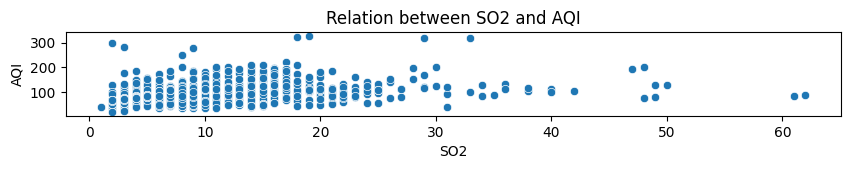

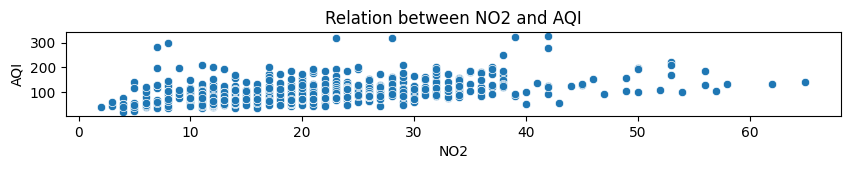

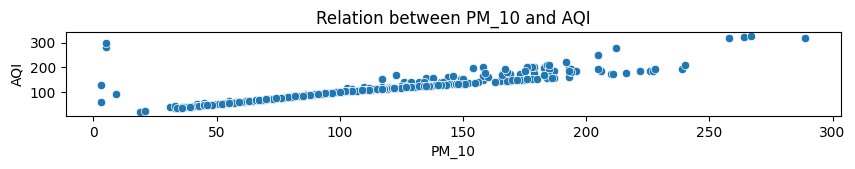

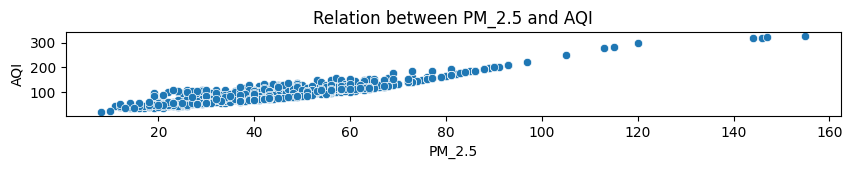

In [ ]:
#Calculationg the relation between pollutant and AQI
pollutant = ['SO2','NO2','PM_10','PM_2.5']
n = 1 # Initialize n correctly
for i in pollutant:
  plt.figure(figsize=(10,5))
  plt.subplot(4,1,n) # Use n+1 for 1-based subplot indexing
  sns.scatterplot(x=i,y='AQI',data=aqi)
  plt.title(f"Relation between {i} and AQI")
  plt.show()
  n=n+1
 # Linear relation between PM_10 and PM_2.5 with AQI. APPLY LR FOR PREDICTION.

In [ ]:
aqi['AQI'] = aqi['AQI'].apply(pd.to_numeric, errors='coerce')
aqi.info() #Making AQI column to numeric

<class 'pandas.core.frame.DataFrame'>
Index: 683 entries, 1 to 849
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   State / Union Territory  683 non-null    object 
 1   City/town                683 non-null    object 
 2   SO2                      683 non-null    float64
 3   NO2                      683 non-null    float64
 4   PM_10                    683 non-null    float64
 5   PM_2.5                   683 non-null    float64
 6   AQI                      683 non-null    int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 42.7+ KB


/tmp/ipython-input-3756324139.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(aqi['SO2'])
/tmp/ipython-input-3756324139.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(aqi['NO2'])


<Axes: xlabel='NO2', ylabel='Density'>

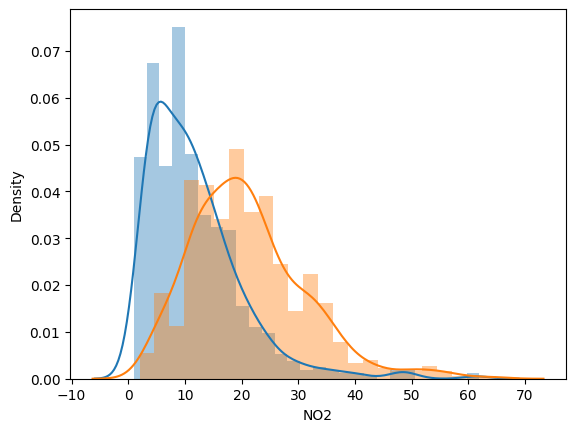

In [ ]:
sns.distplot(aqi['SO2'])
sns.distplot(aqi['NO2'])
#Both are left skewed data (We can normalize that)

In [ ]:
columns = aqi.iloc[:,2:]
columns.corr().iloc[-1]
#Directly co-related with PM_2.5(0.93) and PM_10(0.89) highly co_related.

,AQI
SO2,0.267958
NO2,0.427665
PM_10,0.897508
PM_2.5,0.930684
AQI,1.000000


In [ ]:
#Calculating Average AQI of States/Union Teritories
aqi.groupby('State / Union Territory')['AQI'].mean().sort_values(ascending=False)
#Highest ---> DELHI , Lowest ---> MIZORAM

,AQI
State / Union Territory,
Delhi (UT),262.500000
Bihar,166.083333
Tripura,160.500000
Uttar Pradesh,140.820513
Jharkhand,137.000000
Haryana,133.227273
Rajasthan,123.794118
Punjab,119.250000
Chandigarh (UT),113.500000


Good (0-50)


Satisfactory (51-100)

Moderately Polluted (101-200)

Poor (201-300)

Very Poor (301-400)

Severe (401-500)

In [ ]:
aqi['pollution_cat']=' '
#Fiunction to make the category of Pollution
def check_cat(AQI):
  if AQI<=50:
    return 'Good'
  elif 51<=AQI<=100:
    return 'Satisfactory'
  elif 101<=AQI<=200:
    return' Moderately Polluted'
  elif 201<=AQI<=300:
    return 'Poor'
  elif 301<=AQI<=400:
    return 'Very Poor'
  elif 401<=AQI<=500:
    return 'Severe'

In [ ]:
# Apply the function to the 'AQI' column to create 'pollution_cat'
aqi['pollution_cat'] = aqi['AQI'].apply(check_cat)
display(aqi.head())

,State / Union Territory,City/town,SO2,NO2,PM_10,PM_2.5,AQI,pollution_cat
1,Andhra Pradesh,Amaravati,14.0,11.0,71.0,34.0,71,Satisfactory
2,Andhra Pradesh,Anantapur,10.0,20.0,58.0,24.0,58,Satisfactory
3,Andhra Pradesh,Chittoor,5.0,11.0,57.0,33.0,57,Satisfactory
4,Andhra Pradesh,Kadapa,4.0,22.0,53.0,34.0,56,Satisfactory
6,Andhra Pradesh,Kurnool,7.0,17.0,60.0,30.0,60,Satisfactory


#MODEL TRAINING

In [ ]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [ ]:
from sklearn.model_selection import train_test_split
# Taking the PM_10 and PM_2.5 columns
x_train1,x_test1,y_train1,y_test1=train_test_split(aqi.iloc[:,4:6],aqi['AQI'],test_size=0.2,random_state=42)

In [ ]:
modelpm=lr.fit(x_train1,y_train1)

In [ ]:
y_pred=lr.predict(x_test1)

In [ ]:
from sklearn.metrics import r2_score
r2_score= r2_score(y_pred,y_test1)
print(r2_score)

0.8215582545787263


In [ ]:
x_test1.iloc[0]

,334
PM_10,77.0
PM_2.5,31.0


In [ ]:
from sklearn.model_selection import train_test_split
x_train2,x_test2,y_train2,y_test2=train_test_split(aqi.iloc[:,2:4],aqi['AQI'],test_size=0.2,random_state=42)

In [ ]:
#Normalizing SO2 and NO2
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
x_train_norm = scaler.fit_transform(x_train2.values.reshape(-1,1))
x_test_norm = scaler.transform(x_test2.values.reshape(-1,1))

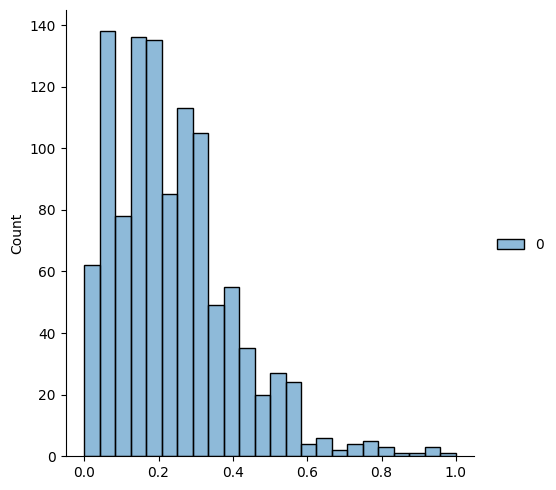

In [ ]:
sns.displot(x_train_norm)

In [ ]:
!pip uninstall -y pandas-profiling numba
!pip install numba==0.52.0
!pip install pandas-profiling==3.1.0


Found existing installation: pandas-profiling 3.1.0
Uninstalling pandas-profiling-3.1.0:
  Successfully uninstalled pandas-profiling-3.1.0
Found existing installation: numba 0.62.1
Uninstalling numba-0.62.1:
  Successfully uninstalled numba-0.62.1
ERROR: Ignored the following versions that require a different python version: 0.52.0 Requires-Python >=3.6,<3.9; 0.52.0rc3 Requires-Python >=3.6,<3.9; 0.53.0 Requires-Python >=3.6,<3.10; 0.53.0rc1.post1 Requires-Python >=3.6,<3.10; 0.53.0rc2 Requires-Python >=3.6,<3.10; 0.53.0rc3 Requires-Python >=3.6,<3.10; 0.53.1 Requires-Python >=3.6,<3.10; 0.54.0 Requires-Python >=3.7,<3.10; 0.54.0rc2 Requires-Python >=3.7,<3.10; 0.54.0rc3 Requires-Python >=3.7,<3.10; 0.54.1 Requires-Python >=3.7,<3.10; 0.55.0 Requires-Python >=3.7,<3.11; 0.55.0rc1 Requires-Python >=3.7,<3.11; 0.55.1 Requires-Python >=3.7,<3.11; 0.55.2 Requires-Python >=3.7,<3.11
ERROR: Could not find a version that satisfies the requirement numba==0.52.0 (from versions: 0.1, 0.2, 0.3, 0

In [ ]:
!pip install ydata-profiling

  Using cached visions-0.8.1-py3-none-any.whl.metadata (11 kB)
  Using cached numba-0.62.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.8 kB)
Using cached numba-0.62.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (3.8 MB)
Using cached visions-0.8.1-py3-none-any.whl (105 kB)
  Attempting uninstall: visions
    Found existing installation: visions 0.7.4
    Uninstalling visions-0.7.4:
      Successfully uninstalled visions-0.7.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas-profiling 3.1.0 requires visions[type_image_path]==0.7.4, but you have visions 0.8.1 which is incompatible.
cudf-cu12 25.10.0 requires numba<0.62.0a0,>=0.60.0, but you have numba 0.62.1 which is incompatible.
cuml-cu12 25.10.0 requires numba<0.62.0a0,>=0.60.0, but you have numba 0.62.1 which is incompatible.


In [ ]:
from ydata_profiling import ProfileReport
AQI = ProfileReport(aqi)
AQI.to_file(output_file='AQI_Report.csv')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 18.16it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/ydata_profiling/profile_report.py:386: UserWarning: Extension .csv not supported. For now we assume .html was intended. To remove this warning, please use .html or .json.
  warnings.warn(


Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
from google.colab import files

# This will prompt a download dialog in your browser
files.download('AQI_Report.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from IPython.display import HTML
import os
# Get the content of the AQI.html file
html_content = open('AQI_Report.html').read()

# Display the content in the notebook
HTML(html_content)